Identify what percent of genes in the high quality GOP terms are excitatory neuron genes.

In [1]:
import pandas as pd

In [2]:
# Load GO-Gene annotations
GO_annots = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/processing/bp_annotations_withGeneData_qc_annotations.csv")

# Differential expression analysis
dea = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/deconvolutingBulk/bin/notebooks/all_gene_marker_scores.csv", index_col=0)

In [17]:
exi_genes = dea.query("logfoldchanges>=3").query("pvals_adj<=0.01").query("group=='Excitatory neurons'")
exi_genes

,group,names,scores,logfoldchanges,pvals,pvals_adj
17724,Excitatory neurons,SV2B,226.082550,9.409174,0.000000,0.000000
17725,Excitatory neurons,SATB2,224.349410,10.210216,0.000000,0.000000
17726,Excitatory neurons,CADPS2,216.986760,9.554445,0.000000,0.000000
17728,Excitatory neurons,CHN1,215.610840,4.620379,0.000000,0.000000
17729,Excitatory neurons,LDB2,215.546420,6.708478,0.000000,0.000000
...,...,...,...,...,...,...
28304,Excitatory neurons,KRT31,2.895236,4.898235,0.003789,0.005348
28312,Excitatory neurons,METTL21C,2.884893,4.024996,0.003915,0.005523
28344,Excitatory neurons,PDE6H,2.829140,4.204880,0.004667,0.006560
28400,Excitatory neurons,TRIM77,2.706127,5.251941,0.006807,0.009509


In [18]:
GO_annots['is_exi'] = GO_annots.DB_Object_Symbol.isin(exi_genes.names)

In [31]:
go_exi_n = GO_annots.groupby("GO ID")['is_exi'].sum()
go_n =GO_annots.groupby("GO ID").size()
go_final = pd.concat([go_n, go_exi_n], axis = 1)
go_final.columns = ['n','n_exi']
go_final['percent']=go_final['n_exi']/go_final['n']
go_final

,n,n_exi,percent
GO ID,,,
GO:0000045,63,1,0.015873
GO:0000070,33,1,0.030303
GO:0000077,35,0,0.000000
GO:0000079,52,1,0.019231
GO:0000082,64,3,0.046875
...,...,...,...
GO:2001237,37,1,0.027027
GO:2001238,27,0,0.000000
GO:2001240,34,0,0.000000


In [32]:
import seaborn as sns

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


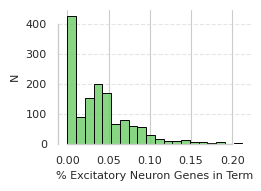

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style and palette
sns.set(style="whitegrid", palette="muted")  # muted colors for publication
sns.set_context("paper")

# Create figure
plt.figure(figsize=(2.7, 2))  # adjust size for your paper

# Plot histogram
sns.histplot(
    go_final, 
    x='percent', 
    bins=20,           # adjust number of bins
    color=sns.color_palette("muted")[2],  # choose a muted color
    edgecolor='black', # optional: black edges for clarity
    alpha=0.8
)

# Labels
plt.xlabel("% Excitatory Neuron Genes in Term", fontsize=8)
plt.ylabel("N", fontsize=8)
# plt.title("Distribution of Percent Values", fontsize=14, fontweight='bold')

# Ticks
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Optional: grid and clean look
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(trim=True)  # remove top and right spines

plt.tight_layout()
plt.savefig("figs/percent_exi_genes.pdf")
plt.show()


In [46]:
go_final.sort_values('percent').sort_values('percent', ascending=False)

,n,n_exi,percent
GO ID,,,
GO:0051966,33,7,0.212121
GO:0050919,39,8,0.205128
GO:0032332,20,4,0.200000
GO:0048814,21,4,0.190476
GO:0090050,21,4,0.190476
...,...,...,...
GO:0000422,38,0,0.000000
GO:0000413,29,0,0.000000
GO:0000387,26,0,0.000000


In [60]:
go_names = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv", sep = "\t")
go_names

,id,name,namespace,CTAffiliated,BrainAffiliated,PBMCAffiliated,def
0,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...
1,GO:0000070,mitotic sister chromatid segregation,biological_process,F,F,F,The cell cycle process in which replicated hom...
2,GO:0000077,DNA damage checkpoint signaling,biological_process,F,F,F,A signal transduction process that contributes...
3,GO:0000079,regulation of cyclin-dependent protein serine/...,biological_process,F,F,F,"Any process that modulates the frequency, rate..."
4,GO:0000082,G1/S transition of mitotic cell cycle,biological_process,F,F,F,The mitotic cell cycle transition by which a c...
...,...,...,...,...,...,...,...
1391,GO:2001237,negative regulation of extrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th..."
1392,GO:2001238,positive regulation of extrinsic apoptotic sig...,biological_process,F,F,F,Any process that activates or increases the fr...
1393,GO:2001240,negative regulation of extrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th..."
1394,GO:2001243,negative regulation of intrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th..."


In [64]:
enrched_terms = go_final.query("percent>=0.15")
enrched_terms.shape


enrched_terms = enrched_terms.merge(go_names, left_index=True, right_on='id')
enrched_terms.drop("PBMCAffiliated", axis = 1).to_csv("data/excitatory_neuron_percnt.csv")

In [68]:
(enrched_terms.BrainAffiliated=='T').sum()

9